
<a href="https://colab.research.google.com/github/kokchun/Machine-learning-AI22/blob/main/Exercises/E01_gradient_descent.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Gradient descent exercises

---
These are introductory exercises in Machine learning with focus in **gradient descent** .

<p class = "alert alert-info" role="alert"><b>Note</b> all datasets used in this exercise can be found under Data folder of the course Github repo</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 0. Simulate dataset (*)

Simulate datasets according to these rules:

- set random seed to 42
- (1000,2) samples from $X \sim \mathcal{U}(0,1)$ , i.e. 1000 rows, 2 columns. 
- 1000 samples from $\epsilon \sim \mathcal{N}(0,1)$
- $y = 3x_1 + 5x_2 + 3 + \epsilon$ , where $x_i$ is column $i$ of $X$

Finally add a column of ones for the intercept to $X$.

<details>

<summary>Hint</summary>

Use for simulating X

´´´
np.random.rand(samples, 2)
´´´

to concatenate with ones, use ```np.c_[..., ...]```

</details>

<details>

<summary>Answer</summary>

```
array([[1.        , 0.37454012, 0.95071431],
       [1.        , 0.73199394, 0.59865848],
       [1.        , 0.15601864, 0.15599452],
       [1.        , 0.05808361, 0.86617615],
       [1.        , 0.60111501, 0.70807258]])

```

</details>

---

In [ ]:
import numpy as np

np.random.seed(42)

# number of samples
n=1000

#Simulate X from uniform(0,1)a
X=np.random.rand(n,2)

#Simulate noise from N(0,1)
epsilon= np.random.randn(n)

#create y 
y = 3*X[:,0] + 5*X[:,1] + 3 + epsilon

#add column of ones for intercept
X=np.c_[np.ones(n), X]

print(X[:5])
print(y[:5])
print(X.shape)
print(y.shape)

[[1.         0.37454012 0.95071431]
 [1.         0.73199394 0.59865848]
 [1.         0.15601864 0.15599452]
 [1.         0.05808361 0.86617615]
 [1.         0.60111501 0.70807258]]
[7.9992093  7.36239389 4.02154963 7.87249707 9.25729255]
(1000, 3)
(1000,)


## 1. Gradient descent - learning rate (*)

Use gradient descent to calculate $\vec{\theta} = (\theta_0, \theta_1, \theta_2)^T$ 

&nbsp; a) Use $\eta = 0.1$ and calculate $\vec{\theta}$ for each fifth epoch from 1 to 500. So the procedure is as follows:
- calculate $\vec{\theta}$ for epochs = 1
- calculate $\vec{\theta}$ for epochs = 6
- ...
- calculate $\vec{\theta}$ for epochs = 496

Plot these $\vec{\theta}$ values against epochs. (*)

&nbsp; b) Do the same as for a) but with learning rate $\eta = 0.01$, 5000 epochs and for each 20th epoch. What do you notice when changing the learning rate? (*)

&nbsp; c) Experiment with larger and smaller $\eta$ and see what happens.

<details>

<summary>Answer</summary>

a) 

<img src="../assets/grad_desc_converg.png" height="200"/>

b) 

<img src="../assets/grad_desc_converg_001.png" height="200"/>

</details>

---

In [15]:
import matplotlib.pyplot as plt

def gradient_descent(X, y, eta, epochs):
   n, p = X.shape
   theta= np.zeros(p)
   theta_history= []

   for _ in range(epochs):

      y_pred= X @ theta
      gradient= (2/n) * X.T @ (y_pred- y)
      theta = theta - eta * gradient
      theta_history.append( theta.copy())
   return np.array(theta_history)

print(f" gradient descent on ln= 0.1 {gradient_descent(X,y, 0.1, 500)}") 
#print(f" gradient descent on ln= 0.01 {gradient_descent(X,y, 0.01)}")   

 gradient descent on ln= 0.1 [[1.4042845  0.73968591 0.79285601]
 [2.37477255 1.2540331  1.352234  ]
 [3.04399583 1.61187395 1.74932265]
 ...
 [3.12097483 2.95386017 4.83249156]
 [3.12090746 2.95391194 4.83256694]
 [3.12084083 2.95396314 4.83264146]]


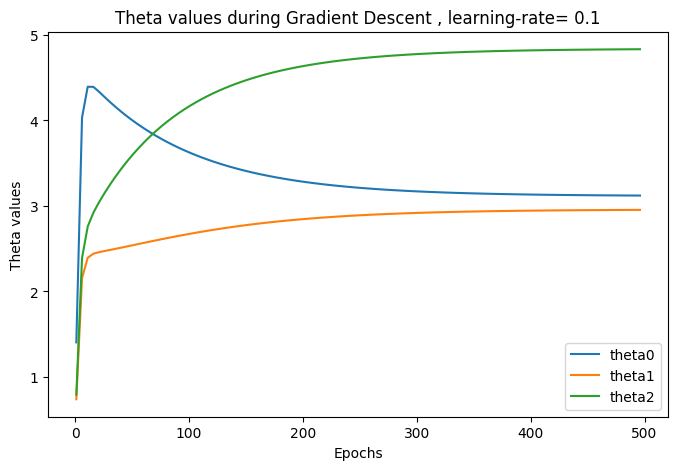

In [16]:
theta_history = gradient_descent(X, y, 0.1, 500)

epochs = np.arange(1, 501, 5)
theta_sample = theta_history[::5]

plt.figure(figsize=(8,5))

plt.plot(epochs, theta_sample[:,0], label="theta0")
plt.plot(epochs, theta_sample[:,1], label="theta1")
plt.plot(epochs, theta_sample[:,2], label="theta2")

plt.xlabel("Epochs")
plt.ylabel("Theta values")
plt.title("Theta values during Gradient Descent , learning-rate= 0.1")

plt.legend()



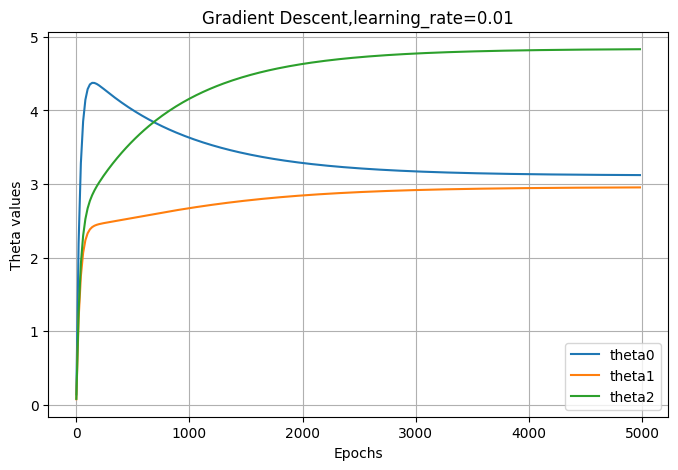

In [17]:
theta_history= gradient_descent(X,y,0.01, 5000)
epochs= np.arange(1,5001,20)
theta_sample = theta_history[::20]

plt.figure(figsize=(8,5))

plt.plot(epochs, theta_sample[:,0], label="theta0")
plt.plot(epochs, theta_sample[:,1], label="theta1")
plt.plot(epochs, theta_sample[:,2], label="theta2")
plt.xlabel("Epochs")
plt.ylabel("Theta values")
plt.title("Gradient Descent,learning_rate=0.01")

plt.legend()
plt.grid()

större learning rate → snabbare konvergens

mindre learning rate → långsammare men stabilare konvergens

## 2. Stochastic Gradient Descent - learning rate (**)

Repeat task 1 but using stochastic gradient descent instead. Also adjust number of epochs to see if you can find convergence. What kind of conclusions can you draw from your experiments. (**)

---

In [18]:
def stochastic_gradient_descent(X, y, eta=0.01, epochs=500):

    n, p = X.shape
    theta = np.zeros(p)
    theta_history = []

    for epoch in range(epochs):

        for i in range(n):

            idx = np.random.randint(n) # vi tar slumpmässig punkt
            xi = X[idx]
            yi = y[idx]

            y_pred = xi @ theta
            gradient = 2 * xi * (y_pred - yi)

            theta = theta - eta * gradient

        theta_history.append(theta.copy())

    return np.array(theta_history)

stochastic_gradient_descent(X, y, eta=0.01, epochs=200)

array([[3.58570502, 2.73333643, 4.20424746],
       [3.34885926, 2.88070774, 4.51767337],
       [3.31299244, 2.87601126, 4.60647174],
       [3.11953265, 2.93610919, 4.62136955],
       [3.24079709, 2.91434071, 4.70854364],
       [3.35969212, 3.08470307, 4.83749147],
       [3.08073778, 2.89921261, 4.77778656],
       [3.27154349, 2.77847286, 5.06844218],
       [3.08443444, 2.84956965, 4.71800505],
       [3.05690073, 2.85982251, 4.79462071],
       [3.13178565, 2.93976431, 4.8683458 ],
       [3.10880956, 2.91852778, 4.70915605],
       [3.19768925, 2.86699008, 4.63275217],
       [3.16290579, 3.00599912, 4.75667729],
       [3.16153459, 3.00592288, 4.79097904],
       [3.14997368, 2.94397496, 4.64591734],
       [3.05053388, 2.93271095, 4.74237429],
       [3.12227233, 2.82930014, 4.83188099],
       [3.07439668, 2.8406801 , 4.84113872],
       [3.07730419, 3.02725645, 5.01276144],
       [3.17083832, 2.93064754, 4.81825714],
       [3.20264917, 2.89244609, 4.84480225],
       [3.

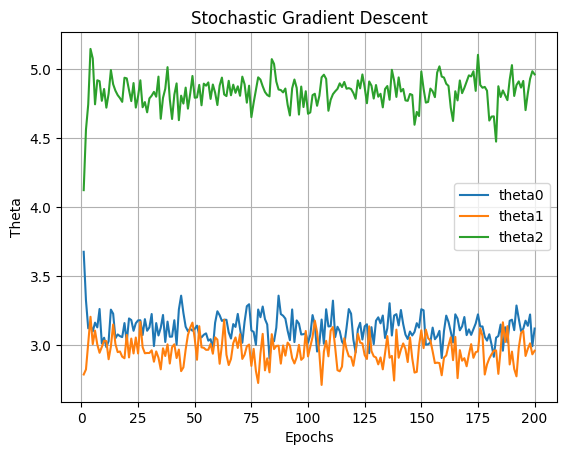

In [19]:
theta_history = stochastic_gradient_descent(X, y, eta=0.01, epochs=200)

epochs = np.arange(1,201)

plt.plot(epochs, theta_history[:,0], label="theta0")
plt.plot(epochs, theta_history[:,1], label="theta1")
plt.plot(epochs, theta_history[:,2], label="theta2")

plt.xlabel("Epochs")
plt.ylabel("Theta")
plt.title("Stochastic Gradient Descent")

plt.legend()
plt.grid()

## 3. Mini Batch Gradient Descent (**)

Now try different sizes of mini-batches and make some exploratory plots to see convergence. Also you can make comparison to the other algorithms by using same $\eta$ and same amount of epochs to see how they differ from each other in terms of convergence. (**)

In [20]:
def mini_batch_gradient_descent(X, y, eta=0.01, epochs=200, batch_size=32):
    n, p = X.shape
    theta = np.zeros(p)
    theta_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(n)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for start in range(0, n, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            gradient = (2 / len(y_batch)) * X_batch.T @ (X_batch @ theta - y_batch)
            theta = theta - eta * gradient

        theta_history.append(theta.copy())

    return np.array(theta_history)



In [21]:
# test olika batch storlek
# storlek = 1 SGD
# storlek = len(X) BGD
batch_sizes = [1, 8, 32, 128, len(X)]
eta = 0.01
epochs_num = 200

histories = {}

for batch_size in batch_sizes:
    histories[batch_size] = mini_batch_gradient_descent(
        X, y, eta=eta, epochs=epochs_num, batch_size=batch_size
    )

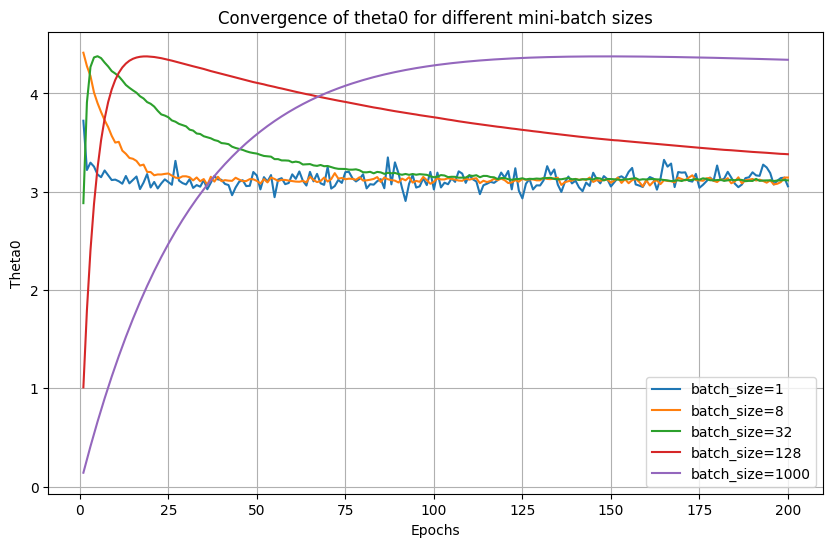

In [22]:
# Plot olika tetta storlek

epochs = np.arange(1, epochs_num + 1)

plt.figure(figsize=(10,6))

for batch_size in batch_sizes:
    plt.plot(epochs, histories[batch_size][:, 0], label=f"batch_size={batch_size}")

plt.xlabel("Epochs")
plt.ylabel("Theta0")
plt.title("Convergence of theta0 for different mini-batch sizes")
plt.legend()
plt.grid()
plt.show()

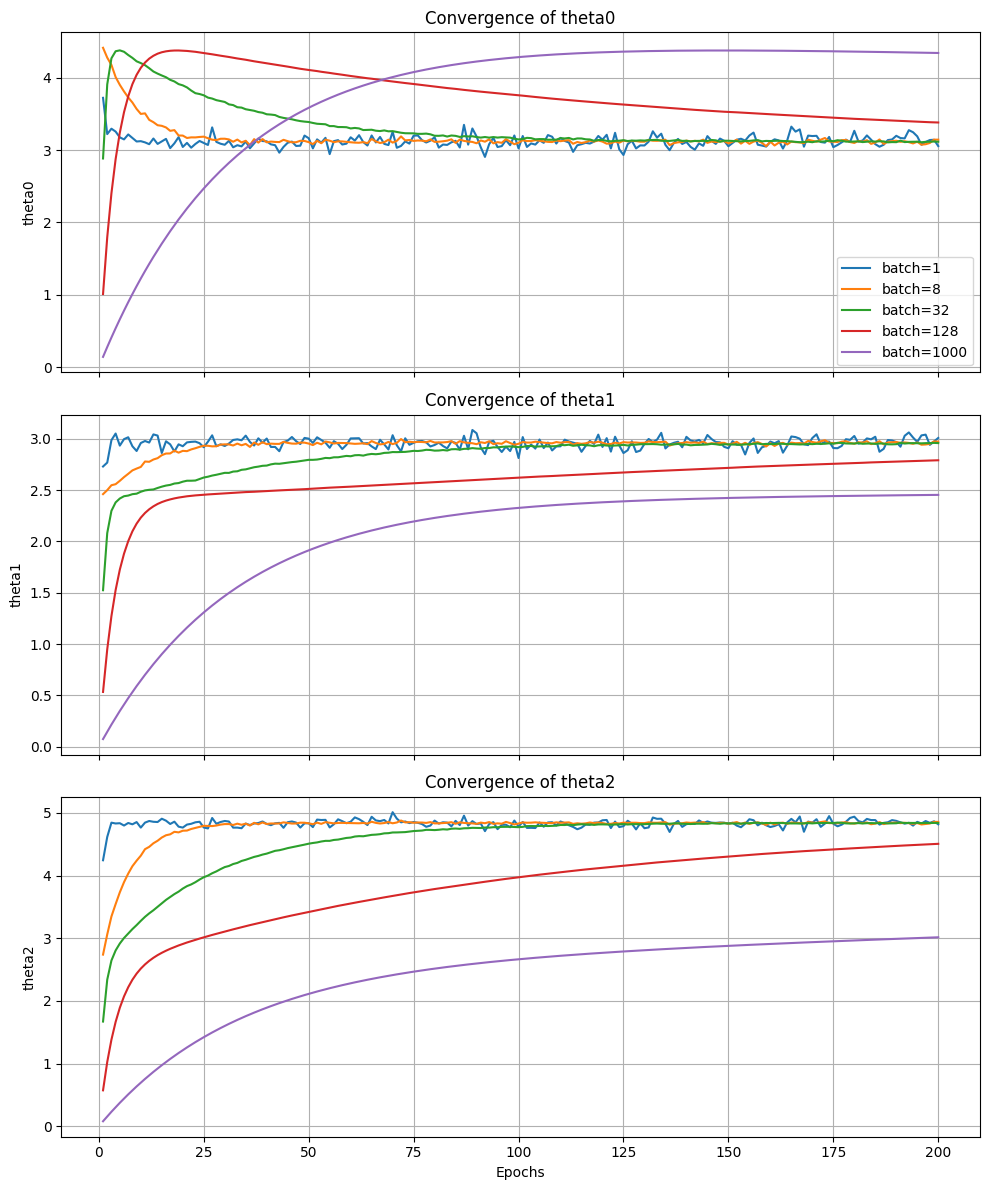

In [23]:
# plot alla parameterar separat

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for batch_size in batch_sizes:
    axes[0].plot(epochs, histories[batch_size][:, 0], label=f"batch={batch_size}")
    axes[1].plot(epochs, histories[batch_size][:, 1], label=f"batch={batch_size}")
    axes[2].plot(epochs, histories[batch_size][:, 2], label=f"batch={batch_size}")

axes[0].set_ylabel("theta0")
axes[0].set_title("Convergence of theta0")
axes[0].grid()

axes[1].set_ylabel("theta1")
axes[1].set_title("Convergence of theta1")
axes[1].grid()

axes[2].set_ylabel("theta2")
axes[2].set_xlabel("Epochs")
axes[2].set_title("Convergence of theta2")
axes[2].grid()

axes[0].legend()
plt.tight_layout()
plt.show()

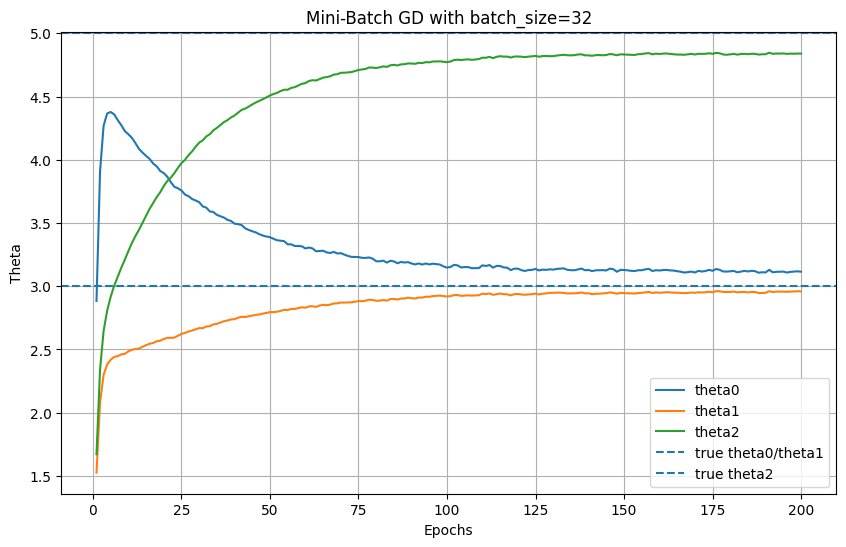

In [24]:
#jämför slutvärden mot sanna parametrar

plt.figure(figsize=(10,6))
plt.plot(epochs, histories[32][:,0], label="theta0")
plt.plot(epochs, histories[32][:,1], label="theta1")
plt.plot(epochs, histories[32][:,2], label="theta2")

plt.axhline(3, linestyle="--", label="true theta0/theta1")
plt.axhline(5, linestyle="--", label="true theta2")

plt.xlabel("Epochs")
plt.ylabel("Theta")
plt.title("Mini-Batch GD with batch_size=32")
plt.legend()
plt.grid()
plt.show()

With small mini-batches, convergence is noisy and resembles stochastic gradient descent. With larger mini-batches, convergence becomes smoother and more stable, resembling batch gradient descent. Mini-batch gradient descent offers a compromise between speed and stability, and moderate batch sizes often perform best in practice